# IMPORTANT: Enter your first name below

In [ ]:
FIRST_NAME=""

# Google Colab Setup

## Part 1: github token setup

1. On your github go to: https://github.com/settings/personal-access-tokens/new
2. Set `Token name *` to: `the-space-cats-colab`
3. Set `Experiation` to `No expiration`
4. Under `Repository access`:
  *   Select option `Only select repositories`
  *   Search and select repo `the-space-cats-project`
5. Under `Permissions`:
    *  Click `Add permissions`
    *  Select option `Contents`
    *  Change `Access: Read-only` to `Access: Read and write`
6. Double check everytjing matches the picture below
7. Save the generated token somewhere safe

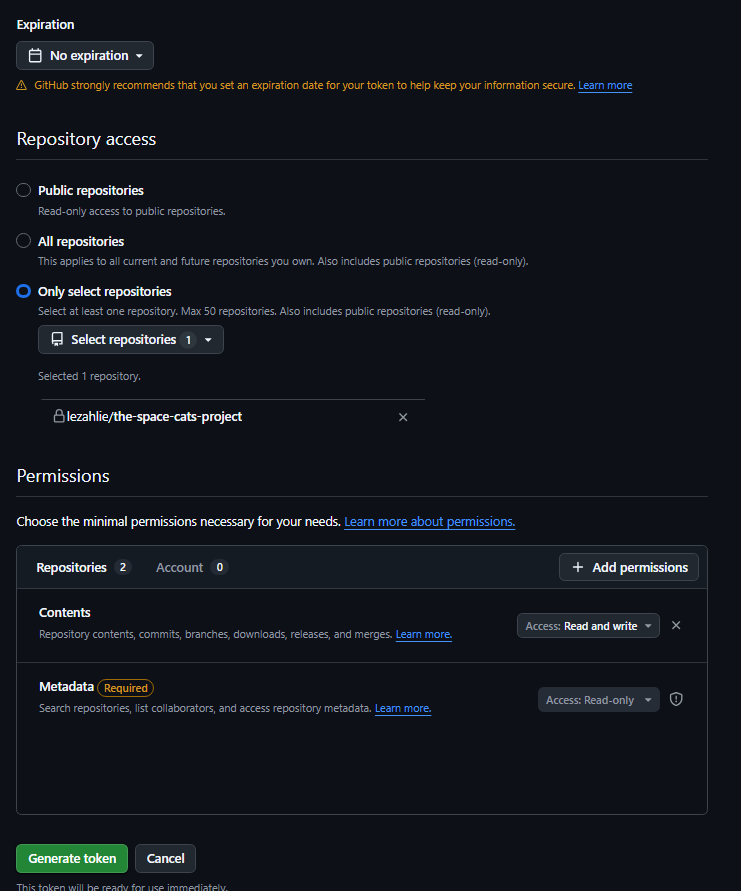

### Part 2: google colab secret

1. In Google Colab select the `Secrets` (key icon) tab
2. Add new secret with name `SPACECATS_GITHUB_TOKEN`
3. Paste the generated token saved from Part 2 - Step 7 in the value field
4. Make sure Notebook access is enabled
5. Confirm with the picture below

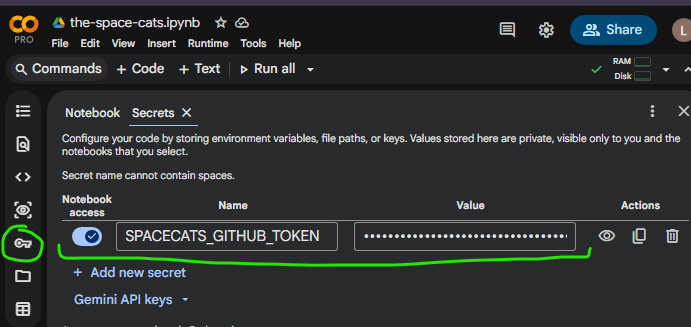

## Part 3: Setup the runtime environment

1. Follow the three screenshots below

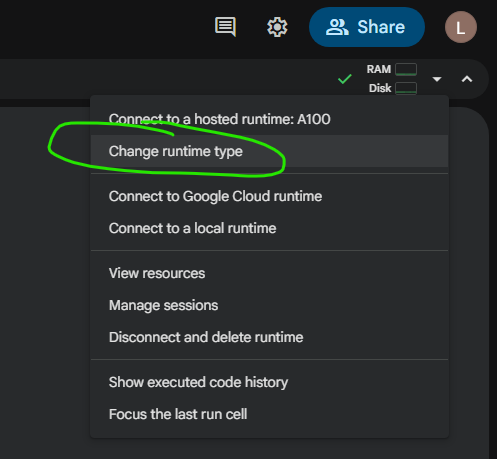

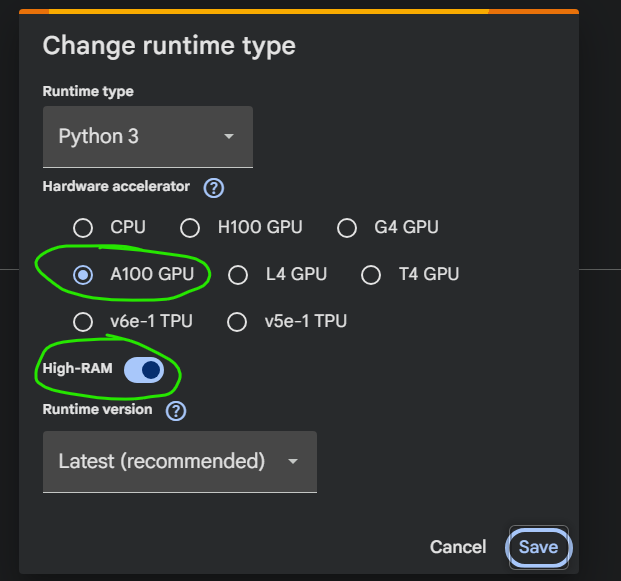

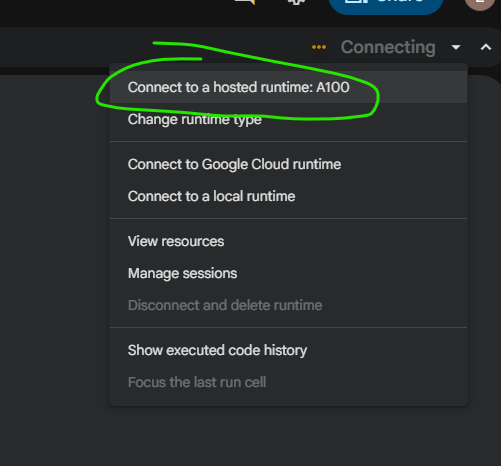

## Part 4: Clone the repo with the new token

### 1. Imports and variables

In [ ]:
from google.colab import userdata, drive
import urllib.parse
import subprocess
import os
import sys
import shutil

def run_cmd(cmd, cwd=None):
    print("$", " ".join(cmd))
    p = subprocess.run(cmd, cwd=cwd, text=True, capture_output=True)
    if p.stdout:
        print(p.stdout)
    if p.stderr:
        print(p.stderr)
    p.check_returncode()

FIRST_NAME=FIRST_NAME.lower()
NUM_CORES = 5

### 2. Clone the repo OR pull updates if already cloned

In [ ]:
drive.mount("/content/drive")

token = urllib.parse.quote(userdata.get("SPACECATS_GITHUB_TOKEN"), safe="")
repo_url = f"https://{token}@github.com/lezahlie/the-space-cats-project.git"
repo_dir = "/content/drive/MyDrive/the-space-cats-project"
branch = FIRST_NAME.lower()  # or set this to your branch name as a string

# clone only if needed
if not os.path.isdir(os.path.join(repo_dir, ".git")):
    run_cmd(["git", "clone", repo_url, repo_dir])

# verify repo
run_cmd(["git", "status"], cwd=repo_dir)

# make sure remote refs are current
run_cmd(["git", "fetch", "origin"], cwd=repo_dir)

# checkout main and update it
run_cmd(["git", "checkout", "main"], cwd=repo_dir)
run_cmd(["git", "pull", "origin", "main"], cwd=repo_dir)

# checkout your branch
branch_exists_local = subprocess.run(
    ["git", "rev-parse", "--verify", branch],
    cwd=repo_dir,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
).returncode == 0

if branch_exists_local:
    run_cmd(["git", "checkout", branch], cwd=repo_dir)
else:
    branch_exists_remote = subprocess.run(
        ["git", "ls-remote", "--exit-code", "--heads", "origin", branch],
        cwd=repo_dir,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
    ).returncode == 0

    if branch_exists_remote:
        run_cmd(["git", "checkout", "-b", branch, f"origin/{branch}"], cwd=repo_dir)
    else:
        run_cmd(["git", "checkout", "-b", branch], cwd=repo_dir)

# bring your branch up to date with main
run_cmd(["git", "pull", "origin", "main"], cwd=repo_dir)

# push branch and set upstream
run_cmd(["git", "push", "-u", "origin", branch], cwd=repo_dir)

## Part 5: Setup the environment
> Note: If a package is already installed, it will auto skip

In [ ]:
%pip install --extra-index-url https://download.pytorch.org/whl/cu118 \
  torch==2.4.1 \
  torchaudio==2.4.1 \
  torchvision==0.19.1 \
  numpy \
  scipy \
  scikit-learn \
  scikit-image \
  torchmetrics \
  h5py \
  jsonschema \
  pandas \
  pyyaml \
  matplotlib \
  seaborn

#### Set project root to python path (required during initialization)

In [ ]:
old_pythonpath = os.environ.get("PYTHONPATH", "")
paths = old_pythonpath.split(":") if old_pythonpath else []

if repo_dir not in paths:
    os.environ["PYTHONPATH"] = f"{repo_dir}:{old_pythonpath}" if old_pythonpath else repo_dir

if repo_dir not in sys.path:
    sys.path.insert(0, repo_dir)

print("PYTHONPATH =", os.environ.get("PYTHONPATH", ""))
print("sys.path[0] =", sys.path[0])

# Test the preprocessing and training pipelines

> 1. Download `galaxiesml_tiny.tar.gz` from: https://gtvault-my.sharepoint.com/:u:/r/personal/lhorace3_gatech_edu/Documents/DLGroupProject_Datasets/galaxiesml_tiny.tar.gz?csf=1&web=1&e=MaHjh7
> 2. Upload the `galaxiesml_tiny.tar.gz` to your google drive `Mydrive` directory
> 3. Run the below cell to extract it to the `data` folder

In [ ]:
!mkdir -p $repo_dir/data
!tar -xzf /content/drive/MyDrive/galaxiesml_tiny.tar.gz -C $repo_dir/data/

### Test the model works with cuda

In [ ]:
%cd $repo_dir
!pwd

### Test preprocessing with the tiny dataset

In [ ]:
!python src/preprocess_data.py \
--input-folder "data/galaxiesml_tiny" \
--output-folder "data/preprocessed" \
--num-cores 2 \
--mask-ratio 0.5 \
--debug

> Note: This is purely for code testing and not the dataset or mask ratio used in the real experimentation.

### Test the tuning works with a tiny grid

In [ ]:
!python src/tune_model.py \
--input-folder "data/preprocessed/galaxiesml_tiny" \
--output-folder "experiments/tune_debug_grid" \
--num-cores {NUM_CORES} \
--gpu-memory-fraction 0.9 \
--debug

### Test the model works with the tiny dataset


In [ ]:
!python src/train_model.py \
--config-file "configs/train_config.json" \
--input-folder "data/preprocessed/galaxiesml_tiny" \
--output-folder "experiments/train_galaxiesml_tiny" \
--gpu-memory-fraction 0.9 \
--num-cores {NUM_CORES} \
--debug

> Important Notes:
> 1. The config will run 5 epochs with hyper-params that over-fit the model.
> 2. On each epoch you should observe the following:
>     - Both Smooth-L1 and SSIM loss values decrease
>     - Validation sample plots show improved reconstruction

# Run the mask ablation experiments

## A. Download the medium reduced dataset

> 1. Download `galaxiesml_medium.tar.gz` from: https://gtvault-my.sharepoint.com/:u:/g/personal/lhorace3_gatech_edu/IQArE7VrCfj2Sqpwv9jNly0JARb2qsCnRMXKgiz8BAt0x-I?e=5ydyFl
> 2. Upload the `galaxiesml_medium.tar.gz` to your google drives `Mydrive` directory
> 3. Run the below cell to extract it to the `data` folder

In [ ]:
!mkdir -p $repo_dir/data
!tar -xzf /content/drive/MyDrive/galaxiesml_medium.tar.gz -C $repo_dir/data/
!ls -lah $repo_dir/data/galaxiesml_medium

## B. Preprocess your mask ratio ablation

In [ ]:
########################################
# Do not edit this cell
########################################

assigned_mask_ratios = {
    "leslie": 0.0,
    "charlie": 0.25,
    "chris": 0.5,
    "wen": 0.75,
}

MASK_RATIO = assigned_mask_ratios[FIRST_NAME]

In [ ]:
!python src/preprocess_data.py \
--input-folder "data/galaxiesml_medium" \
--output-folder "data/preprocessed" \
--num-cores {NUM_CORES} \
--mask-ratio {MASK_RATIO}

## C. Tune the MAE model

### Important Notes: 

1. `tune_model.py` autodetects and recovers completed stages and trials from logs
2. Each trial runs for at most 50 epochs
3. A trial stops early if either of these happens:
   - its validation loss does not improve for 5 consecutive epochs, or
   - it does not beat the current best validation loss within 10 epochs of the best trial's best epoch

In [ ]:
!python src/tune_model.py \
--config-file configs/base_config.json \
--input-folder "data/preprocessed/galaxiesml_medium" \
--output-folder "experiments/train_mae_{FIRST_NAME}_{MASK_RATIO}" \
--gpu-memory-fraction 0.9 \
--num-cores {NUM_CORES}

> - Do not pass `--debug` or it will NOT run the full tuning grid
> - Please keep in mind this may take several days to complete 

## D. Train for more epochs with best hyper-parameters

### 1. First copy your best overall config to the config folder: `configs/{your_name}_config.json`

In [ ]:
!cp -p "experiments/train_mae_{FIRST_NAME}_{MASK_RATIO}/best_overall_config.json" "configs/best_config_{FIRST_NAME}_{MASK_RATIO}.json"

### 2. Train the model with the best params one more time to obtain results for analysis

In [ ]:
!python src/train_model.py \
--config-file "configs/best_config_{FIRST_NAME}_{MASK_RATIO}.json" \
--input-folder "data/preprocessed/galaxiesml_medium" \
--output-folder "experiments/train_mae_{FIRST_NAME}_{MASK_RATIO}" \
--gpu-memory-fraction 0.9 \
--num-cores {NUM_CORES}

> Notes
> - This will run for more epochs with early stopping
> - Save outputs for downstream regression and analysis

## E. Handling downstream analysis

### A. Predict redshift with reconstructions

```python
from src.utils import GalaxyMLDataset

train_path = "./experiments/train_mae_<FIRST_NAME>_<mask_ratio>/artifacts/samples/training_outputs_best.pth"
valid_path = "./experiments/train_mae_<FIRST_NAME>_<mask_ratio>/artifacts/samples/validation_outputs_best.pth"
testing_path = "./experiments/train_mae_<FIRST_NAME>_<mask_ratio>/artifacts/samples/testing_outputs_best.pth"

train_data = GalaxiesMLDataset(train_path, input_key = "y_recon_image", target_key = "y_specz_redshift")
valid_data = GalaxiesMLDataset(valid_path, input_key = "y_recon_image", target_key = "y_specz_redshift")
test_data = GalaxiesMLDataset(test_path, input_key = "y_recon_image", target_key = "y_specz_redshift")
```

### B. Predict redshift with the latents

```python
train_data = GalaxiesMLDataset(train_path, input_key = "z_latent_vector", target_key = "y_specz_redshift")
valid_data = GalaxiesMLDataset(valid_path, input_key = "z_latent_vector", target_key = "y_specz_redshift")
test_data = GalaxiesMLDataset(test_path, input_key = "z_latent_vector", target_key = "y_specz_redshift")
```

### If you want/need the unnormalized data you'll have to do the following:

```python
import torch
from src.utils import GalaxyMLDataset

# 1. Load the transform object from preprocessing

transform_path = "path/to/the-space-cats-project/data/preprocessed/galaxiesml_medium/normalize_transform.pth"
transform = torch.load(transform_path)

# 2-A. Run the following to unscale the true and predicted data

true_redshift_raw = transform.inverse_transform_specz(true_redshift_norm)
pred_redshift_raw = transform.inverse_transform_specz(pred_redshift_norm)

masked_image_raw = transform.inverse_transform(masked_image_norm)
recon_image_raw = transform.inverse_transform(recon_image_norm)

# 2-B. Alternative: Pass the inverse transform function when you load the dataset

train_path = "./experiments/train_mae_<FIRST_NAME>_<MASK_RATIO>/artifacts/samples/training_outputs_best.pth"
valid_path = "./experiments/train_mae_<FIRST_NAME>_<MASK_RATIO>/artifacts/samples/validation_outputs_best.pth"
testing_path = "./experiments/train_mae_<FIRST_NAME>_<MASK_RATIO>/artifacts/samples/testing_outputs_best.pth"

train_data = GalaxiesMLDataset(
    train_path,
    input_key = "y_recon_image",
    target_key = "y_specz_redshift",
    transform=trainer.inverse_transform,
    target_transform=trainer.inverse_transform_specz
)

valid_data = GalaxiesMLDataset(
    valid_path,
    input_key = "y_recon_image",
    target_key = "y_specz_redshift",
    transform=trainer.inverse_transform,
    target_transform=trainer.inverse_transform_specz
)

test_data = GalaxiesMLDataset(
    test_path,
    input_key = "y_recon_image",
    target_key = "y_specz_redshift",
    transform=trainer.inverse_transform,
    target_transform=trainer.inverse_transform_specz
)

```

> Note: Do not need to unnormalize the latents, only the inputs and outputs


## Part 8: Analysis and Visualization

> Here is a rundown of what experiments we need to analyze in the paper.
> Please think about the best ways we can represent results and put any ideas you have!


1. MAE experiments:

   - Encoder
     - Input: `x_masked_image`
     - Output: `z_latent_vector`
   - Decoder
     - Input: `z_latent_vector`
     - Output: `y_recon_image`
     - Target: `y_target_image`
   - Experiments:
     - `MAE-Baseline`: mask_ratio = 0.0
     - `MAE-Ablation`: mask_ratio $\in \{0.0, 0.25, 0.5, 0.75\}$
   - Analysis:
     - (REQUIRED) Testing set: KDE plots for reconstruction error
     - (REQUIRED) Training/validation set: learning curves for loss vs epochs
     - (TBD) Latent visualization: TSNE plots OR something else interesting

2. KNN experiments:

   - KNN Model:
     - Input: `z_latent_vector`
     - Output: `y_pred_redshift`
     - Target: `y_spez_redshift`
    - KNN Tuning:
      - Tune KNN with best results for `MAE-Baseline` and save best params as fixed
    - KNN Training:
      - Train KNN with best results for each `MAE-Ablation` with the fixed params
    - Analysis:
      - (REQUIRED) Testing set: prediction error plots
      - (TBD) Training/validation set: learning curves OR something else interesting

3. CNN experiments:

   - CNN Model:
     - Input: `y_recon_image`
     - Output: `y_pred_redshift`
     - Target: `y_spez_redshift`
    - CNN Tuning:
      - Tune KNN with the original images from the source dataset and save best params as fixed
    - CNN Training:
      - Train CNN with best model outputs results for `MAE-Baseline` and each `MAE-Ablation` with the fixed params
    - Analysis:
      - (REQUIRED) Testing set: prediction error plots
      - (REQUIRED) Training/validation set: learning curves OR something else interesting



## KNN: Latent Quality Analysis

`knn_classifier.py` fits a KNN regressor on the latent vectors (z_latent_vector) from each MAE model to predict redshift. Since KNN has no ability to learn structure on its own, its performance is a test of how well the encoder organized the latent space.

Each person runs this on their own model independently. Leslie runs first because she has the 0 mask baseline. The KNN is tuned on her latent space and the best params are committed to `configs/` so everyone else can use them without re-tuning.


### Step 1: Baseline only (Leslie)

> **Skip if you are not Leslie.** This tunes the KNN on the baseline latent space and saves the best hyperparameters to `configs/knn_best_params.yaml`.

In [ ]:
!python -m src.analysis.knn_classifier \
--input-folder experiments/train_mae_leslie_0.0/artifacts/samples \
--output-folder experiments/knn_results/train_mae_leslie_0.0 \
--debug

In [ ]:
# Copy the best params to configs/ and commit so the rest of the team can use them
!cp experiments/knn_results/train_mae_leslie_0.0/knn_best_params.yaml configs/knn_best_params.yaml

### Step 2: Everyone else (Charlie, Chris, Wen)

> **Skip this step if you are Leslie.** Pull the latest changes first to get `configs/knn_best_params.yaml` from Leslie's run, then evaluate your model with the fixed params.

In [ ]:
!python -m src.analysis.knn_classifier \
--params-file configs/knn_best_params.yaml \
--input-folder experiments/train_mae_{FIRST_NAME}_{MASK_RATIO}/artifacts/samples \
--output-folder experiments/knn_results/train_mae_{FIRST_NAME}_{MASK_RATIO} \
--debug

### Step 3: Commit your results

After your run finishes, copy your metrics JSON to `results/knn/` and commit it.

In [ ]:
!mkdir -p {repo_dir}/results/knn
!cp experiments/knn_results/train_mae_{FIRST_NAME}_{MASK_RATIO}/knn_eval_metrics.json \
   {repo_dir}/results/knn/{FIRST_NAME}_{MASK_RATIO}.json

> Then commit and push:
> ```
> git add results/knn/{FIRST_NAME}_{MASK_RATIO}.json
> git commit -m "add knn results for {FIRST_NAME} mask_ratio={MASK_RATIO}"
> git push
> ```


### Step 4: Aggregation comparison (run once all four results are committed)

Pull the latest changes, then run the cell below. It reads the four committed metrics files and generates the cross-mask-ratio comparison plot.

In [ ]:
import json, os
import numpy as np
from pathlib import Path
from src.analysis.knn_classifier import plot_model_comparison
from src.utils.common import save_to_json

results_dir = Path(f"{repo_dir}/results/knn")
result_files = [
    ("0.0",  results_dir / "leslie_0.0.json"),
    ("0.25", results_dir / "charlie_0.25.json"),
    ("0.5",  results_dir / "chris_0.5.json"),
    ("0.75", results_dir / "wen_0.75.json"),
]

comparison_results = []
for label, path in result_files:
    with open(path) as f:
        metrics = json.load(f)
    test = next(m for m in metrics if m["split"] == "test")
    comparison_results.append({"label": label, "test_r2": test["r2"], "test_mae": test["mae"]})
    print(f"mask_ratio={label}: test_r2={test['r2']:.4f}, test_mae={test['mae']:.6f}")

out_dir = Path(f"{repo_dir}/experiments/knn_results/ablation")
out_dir.mkdir(parents=True, exist_ok=True)
save_to_json(out_dir / "knn_comparison.json", comparison_results)
plot_model_comparison(comparison_results, out_dir / "knn_comparison.png")
print(f"Saved to {out_dir}")